In [1]:
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install tensorboard
%load_ext tensorboard
!pip install torch --upgrade --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.q_values = []  # To collect Q-values for each step
        self.cumulative_q_values = []  # To store cumulative Q-values per episode
        self.release_history=[]
        self.mean_release_history=[]


        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # normalized_release = (action[0] + 1) / 2  # Convert from [-1, 1] to [0, 1]
        normalized_release = np.clip((action[0] + 1) / 2, 0, 1)
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

        # Compute Reward
        deviation_penalty = -abs(self.current_storage - target_storage_af) / target_storage_af
        reward = deviation_penalty

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))  # Save cumulative Q-values
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Initialize TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3("MlpPolicy", env, action_noise=action_noise, verbose=1)

# # Train the model
# n_episodes = 1000
# total_timesteps = n_episodes * episode_length
# model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Initial Storage: 506159.0 AF
Prediction completed and saved.


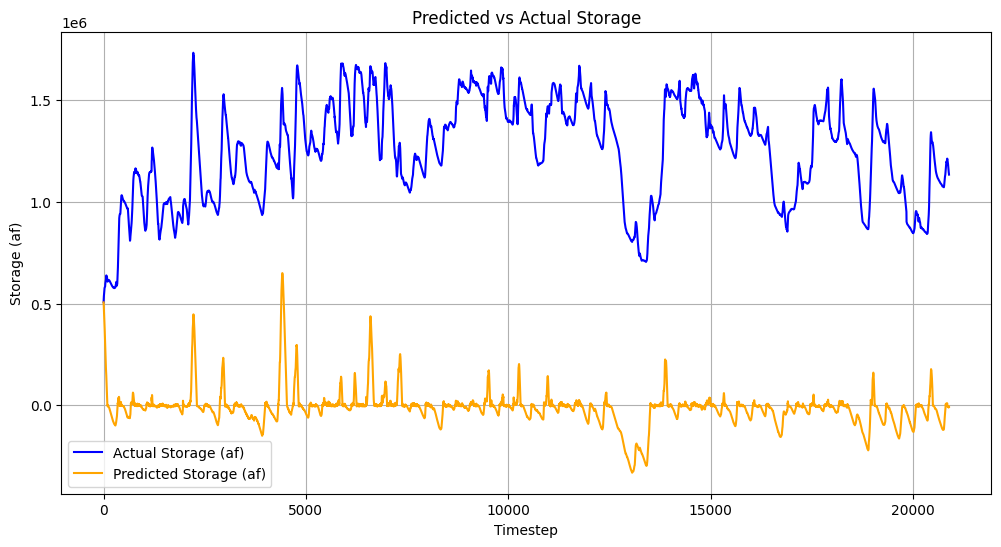

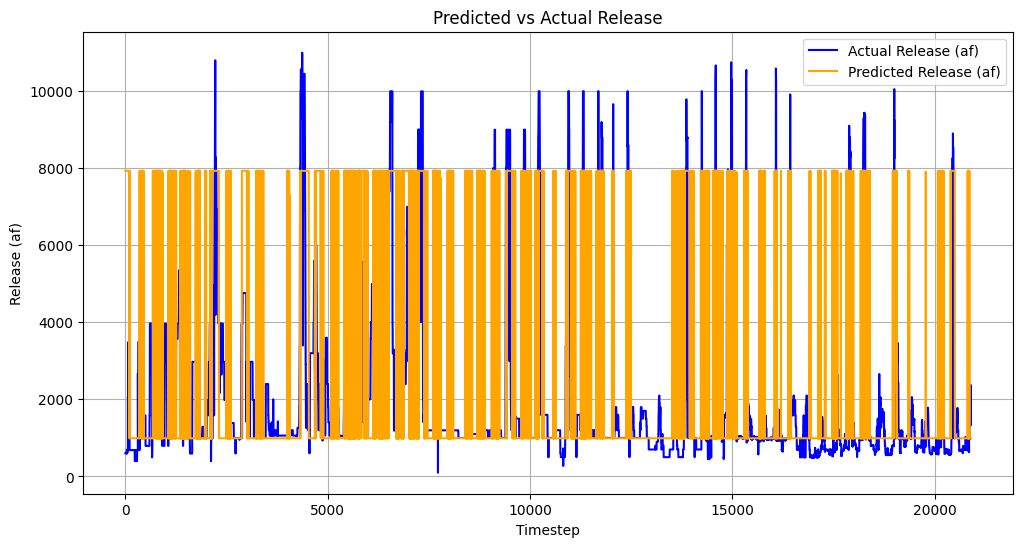

In [ ]:
# Load the trained TD3 agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

In [2]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.q_values = []  # To collect Q-values for each step
        self.cumulative_q_values = []  # To store cumulative Q-values per episode
        self.release_history=[]
        self.mean_release_history=[]


        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # normalized_release = (action[0] + 1) / 2  # Convert from [-1, 1] to [0, 1]
        normalized_release = np.clip((action[0] + 1) / 2, 0, 1)
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

        # Compute Reward
        deviation_penalty = -abs(self.current_storage - target_storage_af) / target_storage_af
        reward = deviation_penalty

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))  # Save cumulative Q-values
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Initialize TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3("MlpPolicy", env, action_noise=action_noise, verbose=1)

# # Train the model
# n_episodes = 1000
# total_timesteps = n_episodes * episode_length
# model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


Streaming output truncated to the last 5000 lines.
observation: [2.5839590e+07 2.1000000e+01 3.8452933e+02]
observation: [2.5838964e+07 2.1000000e+01 6.2436462e+02]
observation: [2.5838576e+07 2.1000000e+01 3.8056512e+02]
observation: [2.5837944e+07 2.1000000e+01 3.8651144e+02]
observation: [2.5837318e+07 2.1000000e+01 3.8254724e+02]
observation: [2.5836688e+07 2.0000000e+01 5.1733069e+02]
observation: [2.5836196e+07 2.0000000e+01 6.4814996e+02]
observation: [2.5835832e+07 2.0000000e+01 1.0406078e+03]
observation: [2.5835862e+07 2.0000000e+01 7.8095135e+02]
observation: [2.5835632e+07 2.0000000e+01 8.9789581e+02]
observation: [2.5835518e+07 2.0000000e+01 9.0186005e+02]
observation: [2.5835410e+07 2.0000000e+01 1.2903536e+03]
observation: [2.5835688e+07 2.0000000e+01 1.1753912e+03]
observation: [2.5835852e+07 2.0000000e+01 1.1674628e+03]
observation: [2.583601e+07 2.000000e+01 9.117706e+02]
observation: [2.583591e+07 2.000000e+01 5.272413e+02]
observation: [2.5835426e+07 2.0000000e+01 6

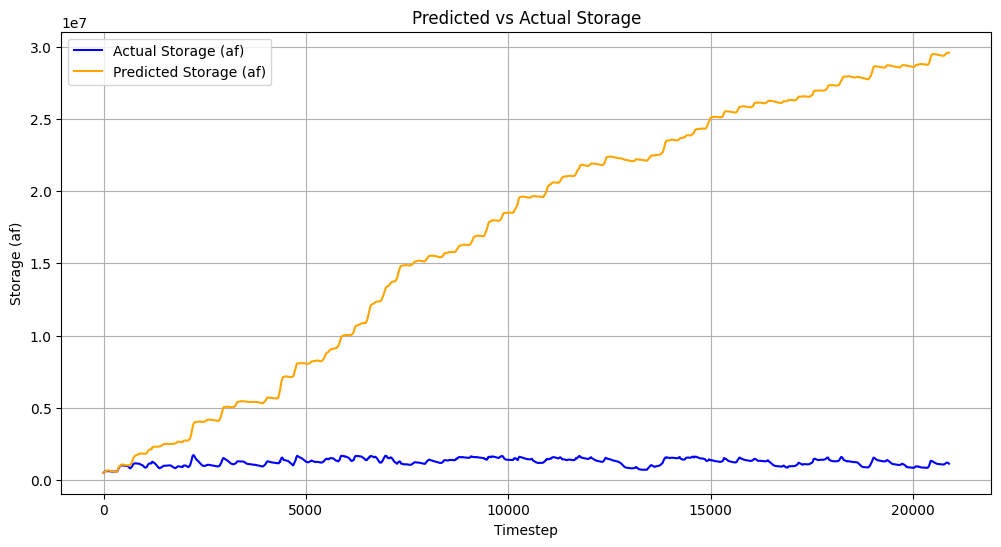

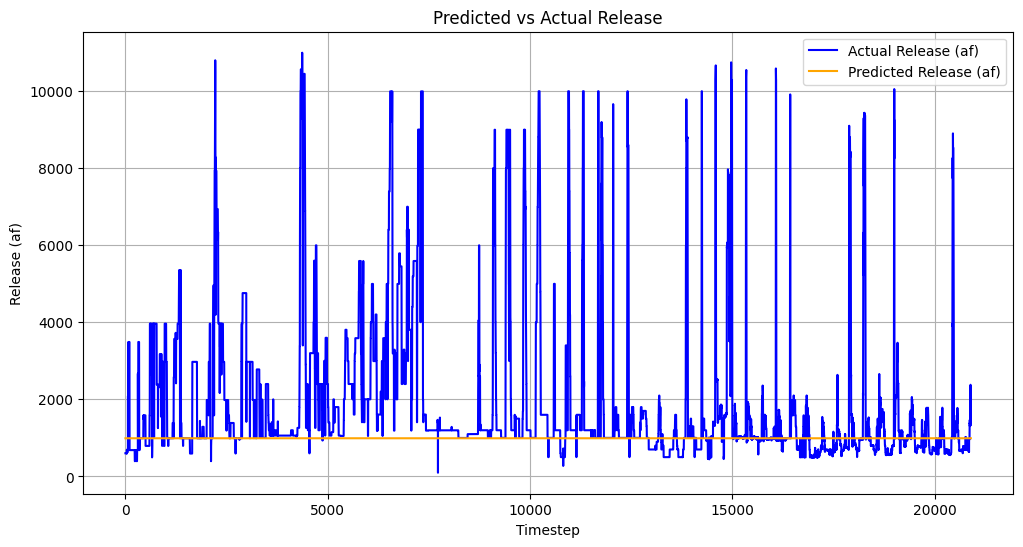

In [4]:
# Load the trained TD3 agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)
    print('observation:', observation)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import torch as th
import gymnasium
from gymnasium import Env
from gymnasium.spaces import Box
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Define storage and release limits
min_storage_af = 500000
max_storage_af = 1800000
initial_storage_af = 500000
target_storage_af = (min_storage_af + max_storage_af) / 2
min_release_af = 500 * 1.98211  # Minimum release in acre-feet
max_release_af = 4000 * 1.98211  # Maximum release in acre-feet

# Load and preprocess data
data = pd.read_csv('/content/Clipped_NAVAJORESERVOIR08-18-2024T16.48.23.csv')
storage = data['Storage (af)'].values
evaporation = data['Evaporation (af)'].values
inflow_cfs = data['Inflow** (cfs)'].values
release_cfs = data['Total Release (cfs)'].values
dataset = np.column_stack((storage, evaporation, inflow_cfs * 1.98211, release_cfs * 1.98211))

# Define the custom Reservoir environment
class ReservoirEnv(Env):
    def __init__(self, dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length):
        super(ReservoirEnv, self).__init__()
        self.data = dataset
        self.episode_length = episode_length
        self.min_storage_af = min_storage_af
        self.max_storage_af = max_storage_af
        self.min_release_af = min_release_af
        self.max_release_af = max_release_af
        self.current_step = 0
        self.episode_step_count = 0
        self.reward_history = []
        self.episode_reward = []
        self.storage_history = []
        self.mean_storage_history = []
        self.q_values = []  # To collect Q-values for each step
        self.cumulative_q_values = []  # To store cumulative Q-values per episode
        self.release_history=[]
        self.mean_release_history=[]


        # Define action space and observation space
        self.action_space = Box(low=-1, high=1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=np.array([self.min_storage_af, np.min(self.data[:, 1]), np.min(self.data[:, 2])]),
                                     high=np.array([self.max_storage_af, np.max(self.data[:, 1]), np.max(self.data[:, 2])]),
                                     dtype=np.float32)

    def reset(self, seed=None):
        self.current_step = np.random.randint(0, len(self.data) - self.episode_length)
        self.episode_step_count = 0
        self.reward_history.clear()
        self.storage_history.clear()
        self.release_history.clear()
        self.current_storage = self.data[self.current_step, 0]
        return self._get_observation(), {}

    def _get_observation(self):
        return np.array([self.current_storage, self.data[self.current_step, 1], self.data[self.current_step, 2]])

    def step(self, action):
        # normalized_release = (action[0] + 1) / 2  # Convert from [-1, 1] to [0, 1]
        normalized_release = np.clip((action[0] + 1) / 2, 0, 1)
        release_af_value = self.min_release_af + normalized_release * (self.max_release_af - self.min_release_af)

        inflow_af = self.data[self.current_step, 2]
        evaporation_af = self.data[self.current_step, 1]
        self.current_storage += inflow_af - evaporation_af - release_af_value

        # Compute Reward
        if self.min_storage_af<=self.current_storage<=self.max_storage_af:
          reward = 1
        else:
          reward=-1

        self.reward_history.append(reward)
        self.storage_history.append(self.current_storage)
        self.current_step += 1
        self.episode_step_count += 1
        done = self.current_step >= len(self.data) or (self.episode_step_count % self.episode_length == 0)

        if done:
            cum_reward = sum(self.reward_history)
            self.episode_reward.append(cum_reward)
            self.mean_storage_history.append(np.mean(self.storage_history))
            self.cumulative_q_values.append(np.sum(self.q_values))  # Save cumulative Q-values
            self.release_history.append(release_af_value)
            self.mean_release_history.append(np.mean(self.release_history))

        observation = self._get_observation() if not done else np.zeros(3)
        return observation, reward, done, False, {}

# Set up environment
episode_length = 120
env = ReservoirEnv(dataset, min_storage_af, max_storage_af, min_release_af, max_release_af, episode_length)

# Initialize TD3 model
n_actions = env.action_space.shape[-1]
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))
model = TD3("MlpPolicy", env, action_noise=action_noise, verbose=1)

# # Train the model
# n_episodes = 1000
# total_timesteps = n_episodes * episode_length
# model.learn(total_timesteps=total_timesteps)

# Save model
model.save("td3_reservoir_agent")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.11/dist-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Initial Storage: 506159.0 AF
Prediction completed and saved.


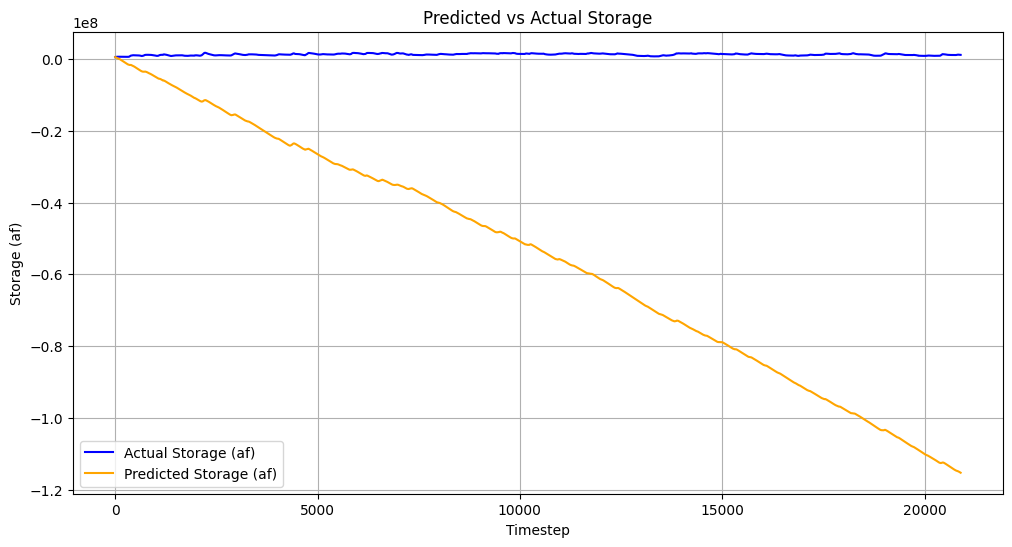

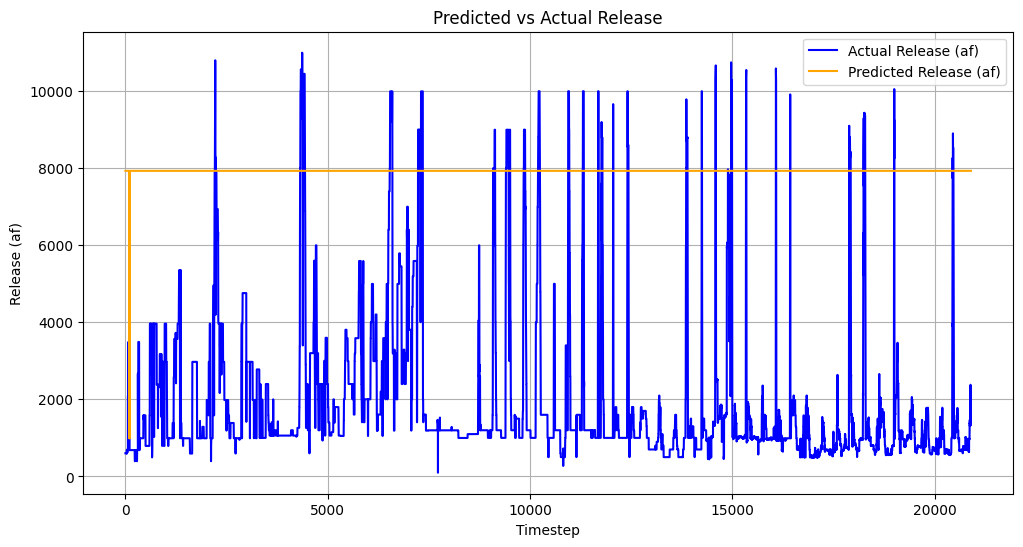

In [ ]:
# Load the trained TD3 agent
from stable_baselines3 import TD3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load trained PPO model
model = TD3.load("td3_reservoir_agent")

# Set up variables for predictions
predicted_storage = []
actual_storage = []
predicted_release = []
actual_release = []

# Initialize current storage
current_storage = dataset[0, 0]  # First storage value from dataset
print(f"Initial Storage: {current_storage} AF")

# Perform predictions for the entire dataset
for i in range(len(dataset)):
    # Get the observation
    observation = np.array([current_storage, dataset[i, 1], dataset[i, 2]], dtype=np.float32)

    # Predict action
    action, _ = model.predict(observation)
    normalized_release = np.clip((action[0] + 1) / 2, 0, 1)

    # Map normalized action to release value in acre-feet
    predicted_release_af = min_release_af + normalized_release * (max_release_af - min_release_af)

    # Extract actual inflow and evaporation from dataset
    inflow_af = dataset[i, 2]
    evaporation_af = dataset[i, 1]

    # Update the current storage using the predicted release, inflow, and evaporation
    current_storage = current_storage + inflow_af - evaporation_af - predicted_release_af

    # Store results for analysis
    predicted_storage.append(current_storage)
    predicted_release.append(predicted_release_af)
    actual_storage.append(dataset[i, 0])  # Actual storage from the dataset
    actual_release.append(dataset[i, 3])  # Actual release from the dataset

# Save results to CSV files
predicted_vs_actual_storage = pd.DataFrame({
    "Predicted Storage (af)": predicted_storage,
    "Actual Storage (af)": actual_storage
})
predicted_vs_actual_release = pd.DataFrame({
    "Predicted Release (af)": predicted_release,
    "Actual Release (af)": actual_release
})

predicted_vs_actual_storage.to_csv("predicted_vs_actual_storage_complete_data.csv", index=False)
predicted_vs_actual_release.to_csv("predicted_vs_actual_release_complete_data.csv", index=False)

print("Prediction completed and saved.")

# Plot Predicted vs Actual Storage
plt.figure(figsize=(12, 6))
plt.plot(actual_storage, label="Actual Storage (af)", color="blue")
plt.plot(predicted_storage, label="Predicted Storage (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Storage (af)")
plt.title("Predicted vs Actual Storage")
plt.legend()
plt.grid()
plt.show()

# Plot Predicted vs Actual Release
plt.figure(figsize=(12, 6))
plt.plot(actual_release, label="Actual Release (af)", color="blue")
plt.plot(predicted_release, label="Predicted Release (af)", color="orange")
plt.xlabel("Timestep")
plt.ylabel("Release (af)")
plt.title("Predicted vs Actual Release")
plt.legend()
plt.grid()
plt.show()